In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
# Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
# XGBoost
from xgboost import XGBClassifier
# Unsupervised
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
 

In [27]:
df = pd.read_csv("bird_counts2.csv")
print(df.head())
print("Dataset Shape:", df.shape)

   rownames  year              species          species_latin  count  hours  \
0         1  1921     American Bittern  Botaurus lentiginosus      0    8.0   
1         2  1921  American Black Duck          Anas rubripes      0    8.0   
2         3  1921        American Coot       Fulica americana      0    8.0   
3         4  1921        American Crow  Corvus brachyrhynchos      0    8.0   
4         5  1921   American Goldfinch         Spinus tristis      0    8.0   

   count_per_hour  count_per_week species_binary  
0             0.0             0.0  American Crow  
1             0.0             0.0  American Crow  
2             0.0             0.0  American Coot  
3             0.0             0.0  American Crow  
4             0.0             0.0  American Crow  
Dataset Shape: (26800, 9)


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26800 entries, 0 to 26799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rownames        26800 non-null  int64  
 1   year            26800 non-null  int64  
 2   species         26800 non-null  str    
 3   species_latin   26800 non-null  str    
 4   count           26800 non-null  int64  
 5   hours           21395 non-null  float64
 6   count_per_hour  21395 non-null  float64
 7   count_per_week  21395 non-null  float64
 8   species_binary  26800 non-null  str    
dtypes: float64(3), int64(3), str(3)
memory usage: 1.8 MB


In [29]:
df.describe()

,rownames,year,count,hours,count_per_hour,count_per_week
count,26800.000000,26800.00000,26800.000000,21395.000000,21395.000000,21395.000000
mean,9311.614627,1970.29903,147.359254,170.596782,1.013175,170.213389
std,5396.261860,27.34457,1630.266380,45.918776,10.517920,1767.010508
min,1.000000,1921.00000,0.000000,8.000000,0.000000,0.000000
25%,4607.750000,1947.00000,0.000000,149.500000,0.000000,0.000000
50%,9328.500000,1970.00000,0.000000,171.000000,0.005031,0.845283
75%,13950.250000,1994.00000,9.000000,203.750000,0.107941,18.134156
max,18706.000000,2017.00000,73000.000000,251.000000,439.024390,73756.097561


In [30]:
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only = True))
 

rownames             0
year                 0
species              0
species_latin        0
count                0
hours             5405
count_per_hour    5405
count_per_week    5405
species_binary       0
dtype: int64


In [31]:
df["bird_present"] = (df["count"] > 0).astype(int)


In [32]:
# 4 Drop Unnecessary Columns
# =====================================================
df = df.drop(["rownames","species","species_latin","species_binary"], axis=1)
 
# =====================================================
# 5 Handle Missing Values
# =====================================================
imputer = SimpleImputer(strategy="mean")
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
 

In [33]:
X = df.drop("bird_present", axis=1)
y = df["bird_present"]
 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 

In [36]:
model_names=[]
accuracy_list=[]
precision_list=[]
recall_list=[]
f1_list=[]

In [37]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    model_names.append(name)
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)

    print("\n======================")
    print(name)
    print("======================")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm / cm.sum(axis=1).reshape(-1, 1)
    cm_percent = (cm_percent * 100).astype(int)

    sns.heatmap(cm_percent, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " Confusion Matrix (%)")
    plt.show()



Logistic Regression
Accuracy: 0.7188432835820896
Precision: 0.7846952010376135
Recall: 0.5073375262054507
F1 Score: 0.6162464985994398

Classification Report
              precision    recall  f1-score   support

         0.0       0.69      0.89      0.78      2975
         1.0       0.78      0.51      0.62      2385

    accuracy                           0.72      5360
   macro avg       0.74      0.70      0.70      5360
weighted avg       0.73      0.72      0.71      5360



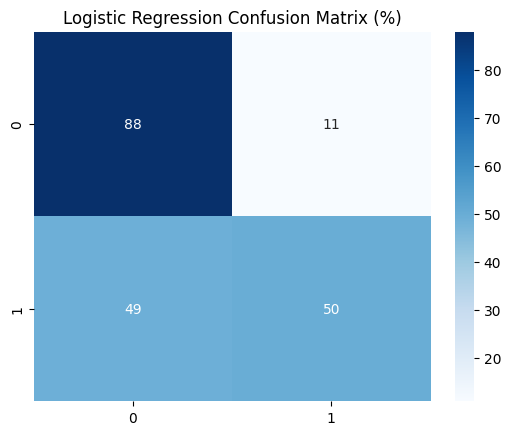


Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



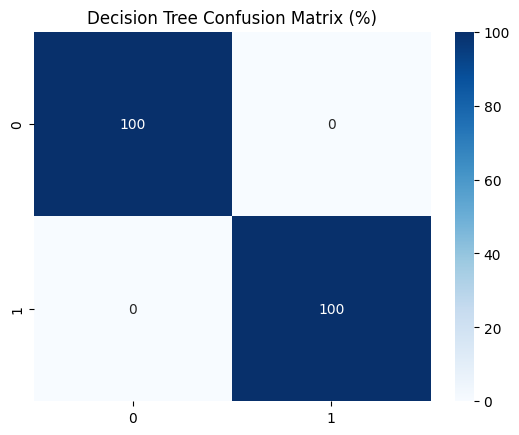


Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



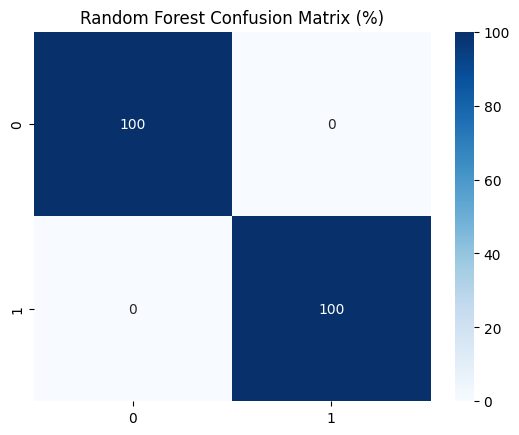


SVM
Accuracy: 0.7255597014925373
Precision: 0.9445525291828794
Recall: 0.4071278825995807
F1 Score: 0.5690008789920891

Classification Report
              precision    recall  f1-score   support

         0.0       0.67      0.98      0.80      2975
         1.0       0.94      0.41      0.57      2385

    accuracy                           0.73      5360
   macro avg       0.81      0.69      0.68      5360
weighted avg       0.79      0.73      0.70      5360



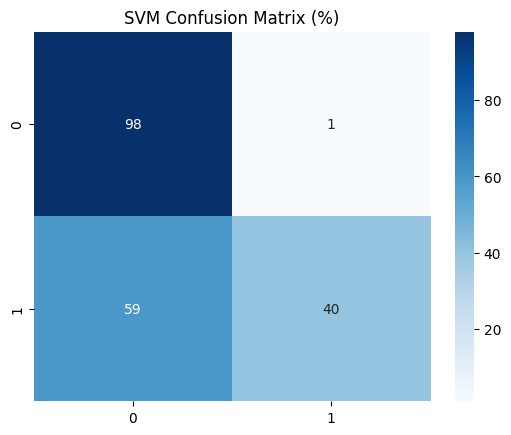


KNN
Accuracy: 0.9996268656716418
Precision: 1.0
Recall: 0.9991614255765199
F1 Score: 0.9995805369127517

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



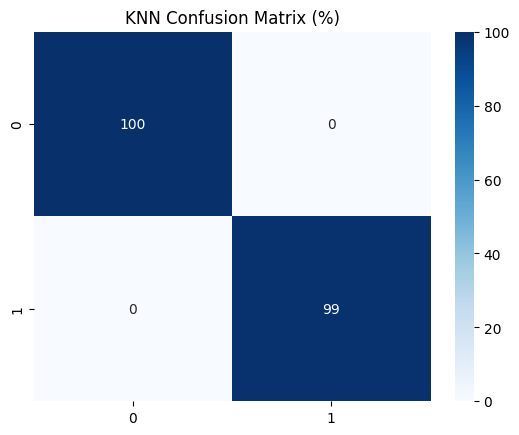


Naive Bayes
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



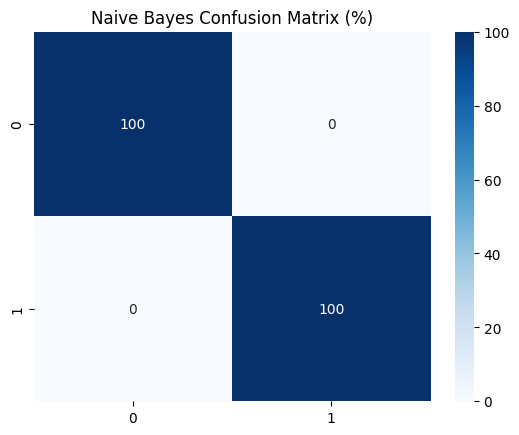


Gradient Boosting
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



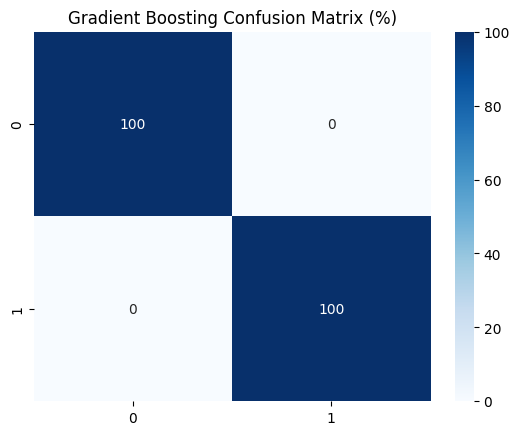


AdaBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



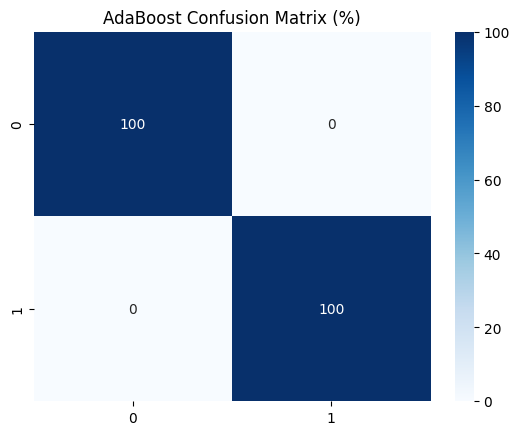


XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2975
         1.0       1.00      1.00      1.00      2385

    accuracy                           1.00      5360
   macro avg       1.00      1.00      1.00      5360
weighted avg       1.00      1.00      1.00      5360



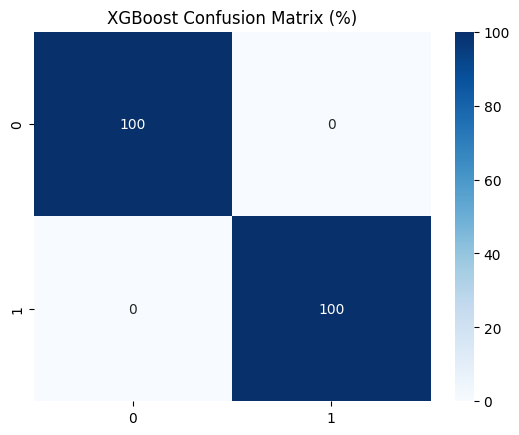

In [38]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate_model(model, name)


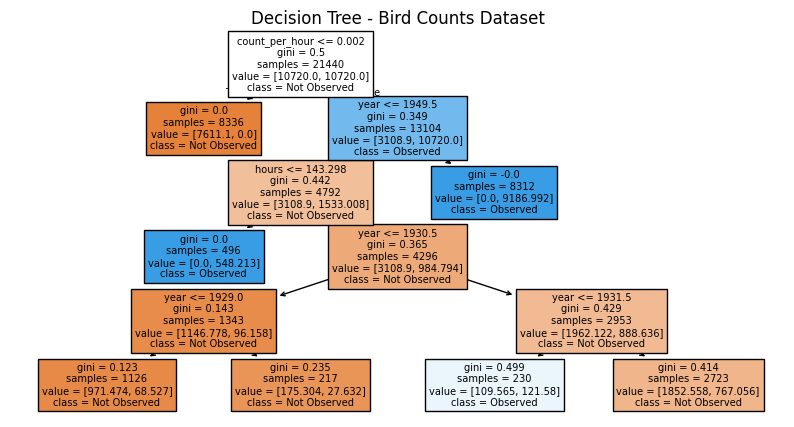

In [48]:
df["observed"] = (df["count"] > 0).astype(int)

X = df[["year", "hours", "count_per_hour", "count_per_week"]]
y = df["observed"]

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

plt.figure(figsize=(10,5))
plot_tree(model,
          feature_names=["year","hours","count_per_hour","count_per_week"],
          class_names=["Not Observed","Observed"],
          filled=True)
plt.title("Decision Tree - Bird Counts Dataset")
plt.show()

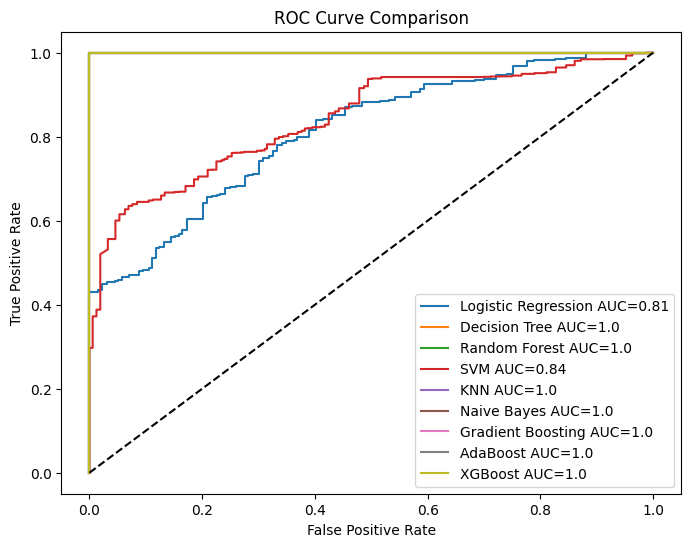

In [40]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=name + " AUC=" + str(round(roc_auc, 2)))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


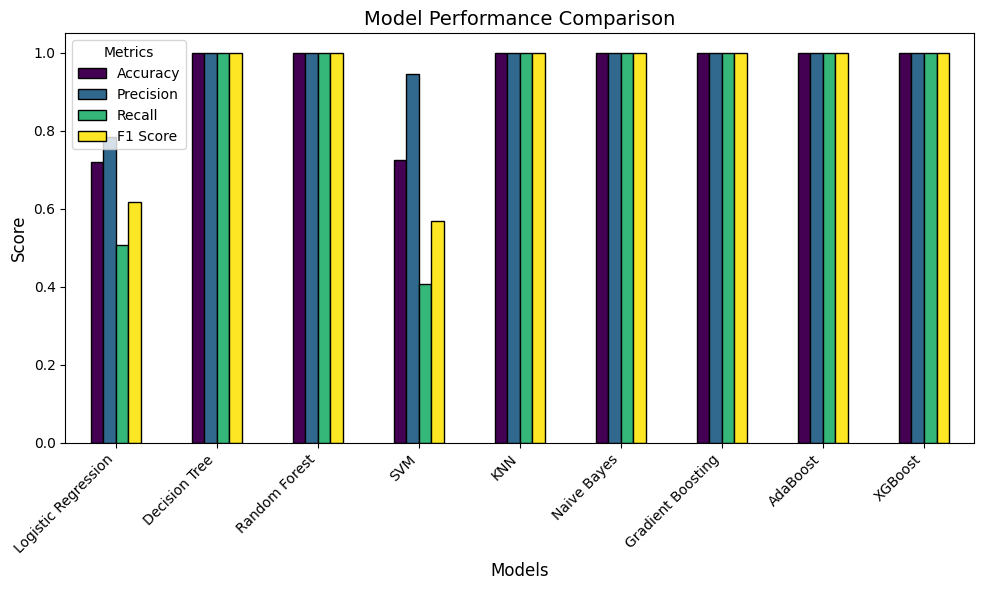

In [41]:
# =====================================================
# Model Performance Comparison
# =====================================================
results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

# Set 'Model' as index for plotting
results.set_index("Model", inplace=True)

# Plot bar chart
ax = results.plot(kind="bar", figsize=(10, 6), colormap="viridis", edgecolor="black")

plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


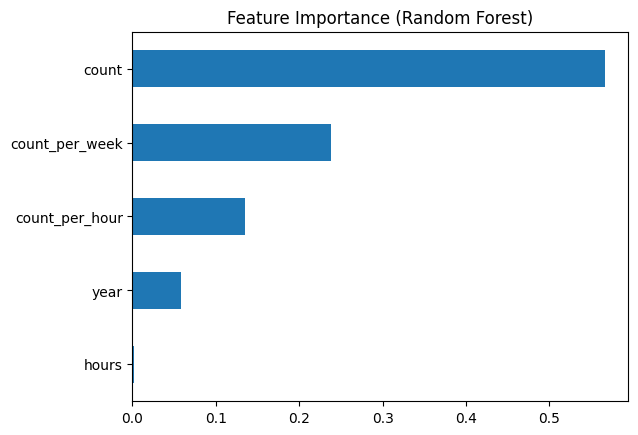

In [42]:
rf = models["Random Forest"]
importance = rf.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()


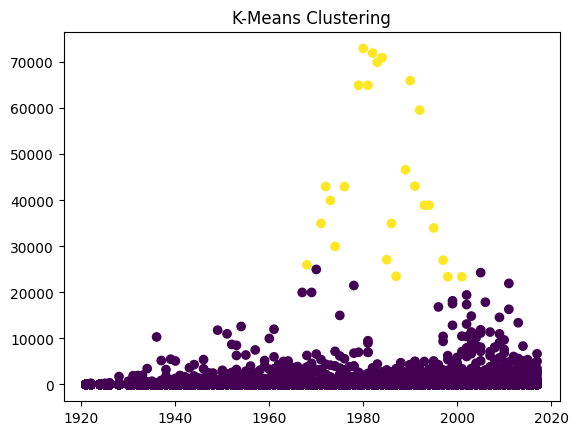

In [43]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.show()


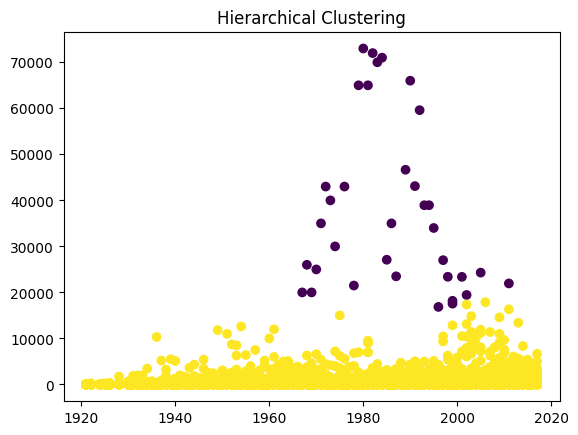

In [44]:
hc = AgglomerativeClustering(n_clusters=2)
clusters = hc.fit_predict(X)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters)
plt.title("Hierarchical Clustering")
plt.show()


In [50]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

print("PCA transformed values (first 5 rows):")
print(X_pca[:5])


Explained variance ratio: [0.59812515 0.3242361 ]
Total variance explained: 0.9223612483188185
PCA transformed values (first 5 rows):
[[-0.38881989 -4.32098485]
 [-0.38881989 -4.32098485]
 [-0.38881989 -4.32098485]
 [-0.38881989 -4.32098485]
 [-0.38881989 -4.32098485]]


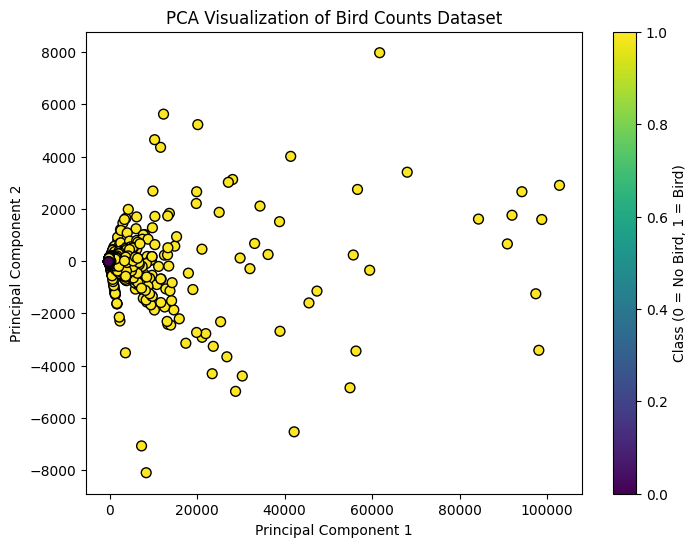

Explained variance ratio: [0.99312065 0.00641742]


In [45]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Scatter plot of PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", edgecolor="k", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Bird Counts Dataset")
plt.colorbar(label="Class (0 = No Bird, 1 = Bird)")
plt.show()

# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

In [52]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

X = X.dropna()
y = y.loc[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_train, y_train)

print("Explained variance ratio:", lda.explained_variance_ratio_)

print("LDA transformed values (first 5 rows):")
print(X_lda[:5])

Explained variance ratio: [1.]
LDA transformed values (first 5 rows):
[[ 0.54535151]
 [ 0.01461145]
 [-0.96055968]
 [-0.28930645]
 [ 1.0094223 ]]
